## ADT Agent Cardiovascular Risk Analysis - Key Findings

**Overall Pattern:**
- No statistically significant association between ADT agent type and cardiovascular risk (χ² p=0.228)
- Sample size limitations prevent definitive conclusions, especially for rare ADT combinations

**Risk Rates by Major ADT Agents:**
- **Firmagon**: 47.1% risk rate (8/17 patients) - highest among adequately-powered groups
- **Bicalutamide**: 44.4% risk rate (12/27 patients)
- **Lupron**: 34.0% risk rate (18/53 patients)
- **Orgovyx**: 32.5% risk rate (26/80 patients) - lowest risk, largest sample

**Key Observations:**
- Combination therapies showed 100% risk rates, but sample sizes were too small (n=1-2) for meaningful interpretation
- Firmagon and Bicalutamide showed numerically higher risk rates (~47% and 44%) compared to Lupron and Orgovyx (~34% and 33%)
- None of the pairwise comparisons reached statistical significance (all p>0.05)

**Clinical Interpretation:**
- Orgovyx appears to have the lowest cardiovascular risk profile among commonly-used agents
- Firmagon may warrant closer cardiovascular monitoring, though this requires validation in larger samples
- The lack of statistical significance likely reflects small sample size rather than true absence of differences
- Combination and sequential therapies need further study with larger cohorts

**Study Limitations:**
- Small sample sizes for individual ADT agents limit statistical power
- Multiple rare ADT combinations (n=1-2) inflate the cross-tabulation but don't contribute meaningful data
- Non-standardized combination therapy entries suggest data quality issues that may require additional cleaning

Dataset shape: (239, 60)

Target variable distribution:
at_risk
0.0    124
1.0     79
NaN     36
Name: count, dtype: int64

Patients with ADT agent and at_risk data: 192

ADT agent distribution:
adt_agent
Orgovyx                              80
Lupron                               53
Bicalutamide                         27
Firmagon                             17
bicalutamide to lupron to orgovyx     2
lupron + casodex to lupron            2
lupron, orgovyx (d/c)                 2
casodex to firmagon                   1
casodex to lupron                     1
lupron + bicalutamide                 1
casodex to lpron                      1
bicalutamide + lupron                 1
bicalutamide, then lupron             1
lupron, firmagon                      1
orgovyx and nubeqa                    1
lupon                                 1
Name: count, dtype: int64

CROSS-TABULATION: ADT Agent vs At-Risk Status
at_risk                            0.0  1.0  All
adt_agent                        

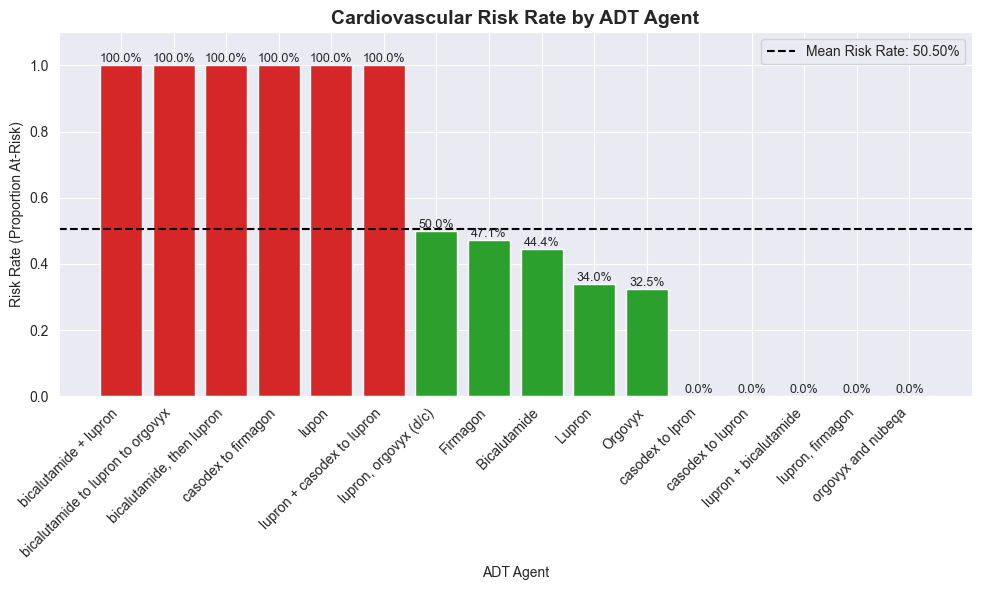

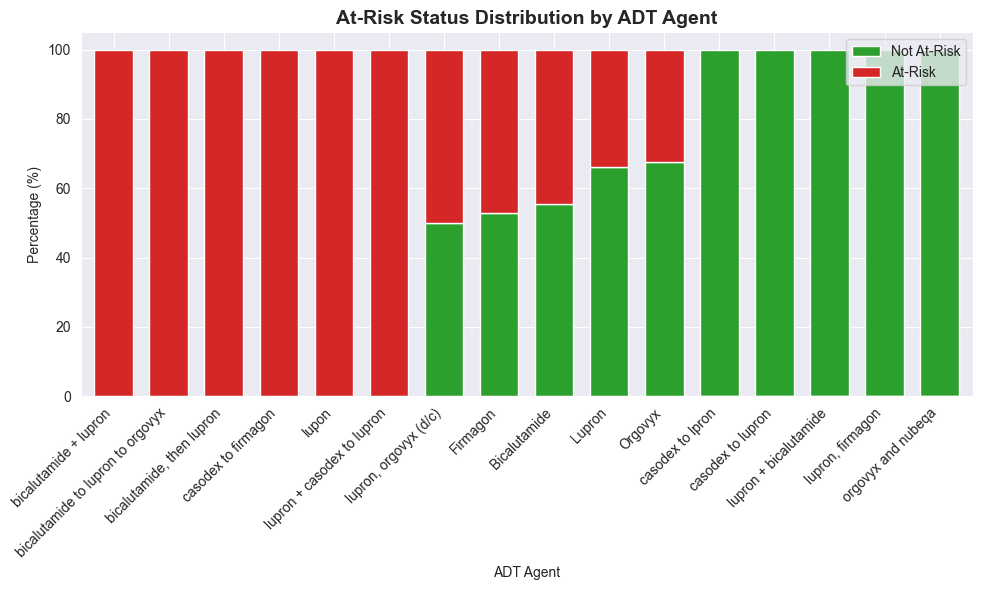


SUMMARY: HIGHEST RISK ADT AGENTS

1. bicalutamide + lupron
   Risk Rate: 100.0%
   Patients: 1 (1 at-risk)
   P-value vs others: 0.3802 (No)

2. bicalutamide to lupron to orgovyx
   Risk Rate: 100.0%
   Patients: 2 (2 at-risk)
   P-value vs others: 0.1433 (No)

3. bicalutamide, then lupron
   Risk Rate: 100.0%
   Patients: 1 (1 at-risk)
   P-value vs others: 0.3802 (No)



In [41]:
import os
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
import matplotlib.pyplot as plt
import seaborn as sns


# Load the preprocessed data
BASE_FILE = os.path.join("..", "..", "data", "processed", "cardio_onc_prostate_06_broad_clean.csv")
df = pd.read_csv(BASE_FILE)

print(f"Dataset shape: {df.shape}")
print(f"\nTarget variable distribution:")
print(df['at_risk'].value_counts(dropna = False))

# ADT Agent Risk Analysis

# Filter to patients with ADT agent data and at_risk outcome
analysis_df = df[df['adt_agent'].notna() & df['at_risk'].notna()].copy()

print(f"\nPatients with ADT agent and at_risk data: {len(analysis_df)}")
print(f"\nADT agent distribution:")
print(analysis_df['adt_agent'].value_counts())

# Cross-tabulation: ADT agent vs at_risk
crosstab = pd.crosstab(
    analysis_df['adt_agent'],
    analysis_df['at_risk'],
    margins = True
)

print("\n" + "=" * 60)
print("CROSS-TABULATION: ADT Agent vs At-Risk Status")
print("=" * 60)
print(crosstab)

# Calculate risk rates by ADT agent
risk_by_adt = analysis_df.groupby('adt_agent').agg({
    'at_risk': ['sum', 'count', 'mean']
}).round(3)

risk_by_adt.columns = ['at_risk_count', 'total_patients', 'risk_rate']
risk_by_adt = risk_by_adt.sort_values('risk_rate', ascending = False)

print("\n" + "=" * 60)
print("RISK RATES BY ADT AGENT (Sorted by Risk)")
print("=" * 60)
print(risk_by_adt)

# Statistical significance testing
print("\n" + "=" * 60)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 60)

# Chi-square test for overall association
contingency_table = pd.crosstab(analysis_df['adt_agent'], analysis_df['at_risk'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square test:")
print(f"  Chi2 statistic: {chi2:.4f}")
print(f"  P-value: {p_value:.4f}")
print(f"  Degrees of freedom: {dof}")
print(f"  Significant at α=0.05: {'Yes' if p_value < 0.05 else 'No'}")

# Pairwise comparisons (Fisher's exact test for each ADT vs all others)
print("\n" + "=" * 60)
print("PAIRWISE COMPARISONS (Each ADT vs All Others)")
print("=" * 60)

adt_agents = analysis_df['adt_agent'].unique()
pairwise_results = []

for adt in adt_agents:
    # Create binary variable: this ADT vs all others
    is_this_adt = (analysis_df['adt_agent'] == adt).astype(int)

    # 2x2 contingency table
    table = pd.crosstab(is_this_adt, analysis_df['at_risk'])

    # Fisher's exact test (better for small samples)
    if table.shape == (2, 2):
        odds_ratio, p_val = fisher_exact(table)

        # Calculate risk in this ADT group vs others
        risk_this_adt = analysis_df[analysis_df['adt_agent'] == adt]['at_risk'].mean()
        risk_others = analysis_df[analysis_df['adt_agent'] != adt]['at_risk'].mean()

        pairwise_results.append({
            'ADT_Agent': adt,
            'Risk_Rate': risk_this_adt,
            'Risk_Rate_Others': risk_others,
            'Odds_Ratio': odds_ratio,
            'P_Value': p_val,
            'Significant': 'Yes' if p_val < 0.05 else 'No'
        })

pairwise_df = pd.DataFrame(pairwise_results).sort_values('Risk_Rate', ascending = False)
print(pairwise_df.to_string(index = False))

# Visualization 1: Risk rates by ADT agent
fig, ax = plt.subplots(figsize = (10, 6))

risk_by_adt_plot = risk_by_adt.reset_index()
bars = ax.bar(
    range(len(risk_by_adt_plot)),
    risk_by_adt_plot['risk_rate'],
    color = ['#d62728' if rate > risk_by_adt_plot['risk_rate'].mean()
             else '#2ca02c' for rate in risk_by_adt_plot['risk_rate']]
)

ax.axhline(
    y = risk_by_adt_plot['risk_rate'].mean(),
    color = 'black',
    linestyle = '--',
    label = f"Mean Risk Rate: {risk_by_adt_plot['risk_rate'].mean():.2%}"
)

ax.set_xticks(range(len(risk_by_adt_plot)))
ax.set_xticklabels(risk_by_adt_plot['adt_agent'], rotation = 45, ha = 'right')
ax.set_ylabel('Risk Rate (Proportion At-Risk)')
ax.set_xlabel('ADT Agent')
ax.set_title('Cardiovascular Risk Rate by ADT Agent', fontsize = 14, fontweight = 'bold')
ax.legend()
ax.set_ylim(0, max(risk_by_adt_plot['risk_rate']) * 1.1)

# Add value labels on bars
for i, (bar, rate) in enumerate(zip(bars, risk_by_adt_plot['risk_rate'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height,
            f'{rate:.1%}',
            ha = 'center', va = 'bottom', fontsize = 9)

plt.tight_layout()
# plt.savefig('../outputs/adt_risk_rates.png', dpi = 300, bbox_inches = 'tight')
plt.show()

# Visualization 2: Stacked bar chart showing at-risk vs not at-risk
fig, ax = plt.subplots(figsize = (10, 6))

crosstab_pct = pd.crosstab(
    analysis_df['adt_agent'],
    analysis_df['at_risk'],
    normalize = 'index'
) * 100

crosstab_pct = crosstab_pct.loc[risk_by_adt.index]  # Sort by risk rate

crosstab_pct.plot(
    kind = 'bar',
    stacked = True,
    ax = ax,
    color = ['#2ca02c', '#d62728'],
    width = 0.7
)

ax.set_ylabel('Percentage (%)')
ax.set_xlabel('ADT Agent')
ax.set_title('At-Risk Status Distribution by ADT Agent', fontsize = 14, fontweight = 'bold')
ax.legend(['Not At-Risk', 'At-Risk'], loc = 'upper right')
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha = 'right')

plt.tight_layout()
# plt.savefig('../outputs/adt_risk_distribution.png', dpi = 300, bbox_inches = 'tight')
plt.show()

# Summary report
print("\n" + "=" * 60)
print("SUMMARY: HIGHEST RISK ADT AGENTS")
print("=" * 60)

top_3 = risk_by_adt.head(3)
for idx, (adt, row) in enumerate(top_3.iterrows(), 1):
    print(f"\n{idx}. {adt}")
    print(f"   Risk Rate: {row['risk_rate']:.1%}")
    print(f"   Patients: {int(row['total_patients'])} ({int(row['at_risk_count'])} at-risk)")

    # Find p-value from pairwise comparison
    p_val = pairwise_df[pairwise_df['ADT_Agent'] == adt]['P_Value'].values[0]
    sig = pairwise_df[pairwise_df['ADT_Agent'] == adt]['Significant'].values[0]
    print(f"   P-value vs others: {p_val:.4f} ({sig})")

print("\n" + "=" * 60)

## NHT Agent Cardiovascular Risk Analysis - Key Findings

**Overall Pattern:**
- No statistically significant association between NHT agent type and cardiovascular risk (χ² p=0.460)
- All four NHT agents have adequate sample sizes (n=13-89) for meaningful comparison
- Risk rates range from 31% to 45% across agents

**Risk Rates by NHT Agent:**
- **Abiraterone**: 44.9% risk rate (40/89 patients) - **highest risk**
- **Darolutamide**: 35.4% risk rate (29/82 patients)
- **Enzalutamide**: 31.6% risk rate (6/19 patients)
- **Apalutamide**: 30.8% risk rate (4/13 patients) - lowest risk

**Key Observations:**
- Abiraterone shows ~45% higher odds of cardiovascular risk vs. other NHTs (OR=1.57), though not statistically significant (p=0.147)
- 13.9 percentage point difference between highest (Abiraterone 44.9%) and lowest (Apalutamide 30.8%) risk agents
- The three newer-generation agents (Darolutamide, Enzalutamide, Apalutamide) cluster together at ~31-35% risk
- None of the pairwise comparisons reached statistical significance (all p>0.14)

**Clinical Interpretation:**
- Abiraterone appears to carry higher cardiovascular risk burden compared to other NHT agents, warranting closer monitoring
- Darolutamide, Enzalutamide, and Apalutamide show similar, lower risk profiles
- The trend toward higher risk with Abiraterone (p=0.147) may become significant with larger sample sizes
- Results are more robust than ADT analysis due to better-balanced sample sizes and cleaner data

**Comparative Context:**
- NHT data quality is superior to ADT data (4 clean categories vs. 16 messy ADT entries)
- All NHT agents have adequate statistical power (n≥13), unlike many ADT combinations
- The 31-45% overall risk range for NHTs is comparable to the 33-47% range seen in major ADT agents

**Clinical Recommendation:**
- Patients on Abiraterone may benefit from enhanced cardiovascular monitoring and preventive interventions
- Consider cardiovascular risk profile when selecting between Abiraterone and newer-generation NHTs in borderline cases

Dataset shape: (239, 60)

Target variable distribution:
at_risk
0.0    124
1.0     79
NaN     36
Name: count, dtype: int64

Patients with NHT agent and at_risk data: 203

NHT agent distribution:
specific_nht_used
Abiraterone     89
Darolutamide    82
Enzalutamide    19
Apalutamide     13
Name: count, dtype: int64

CROSS-TABULATION: NHT Agent vs At-Risk Status
at_risk            0.0  1.0  All
specific_nht_used               
Abiraterone         49   40   89
Apalutamide          9    4   13
Darolutamide        53   29   82
Enzalutamide        13    6   19
All                124   79  203

RISK RATES BY NHT AGENT (Sorted by Risk)
                   at_risk_count  total_patients  risk_rate
specific_nht_used                                          
Abiraterone                 40.0              89      0.449
Darolutamide                29.0              82      0.354
Enzalutamide                 6.0              19      0.316
Apalutamide                  4.0              13      0.308

STAT

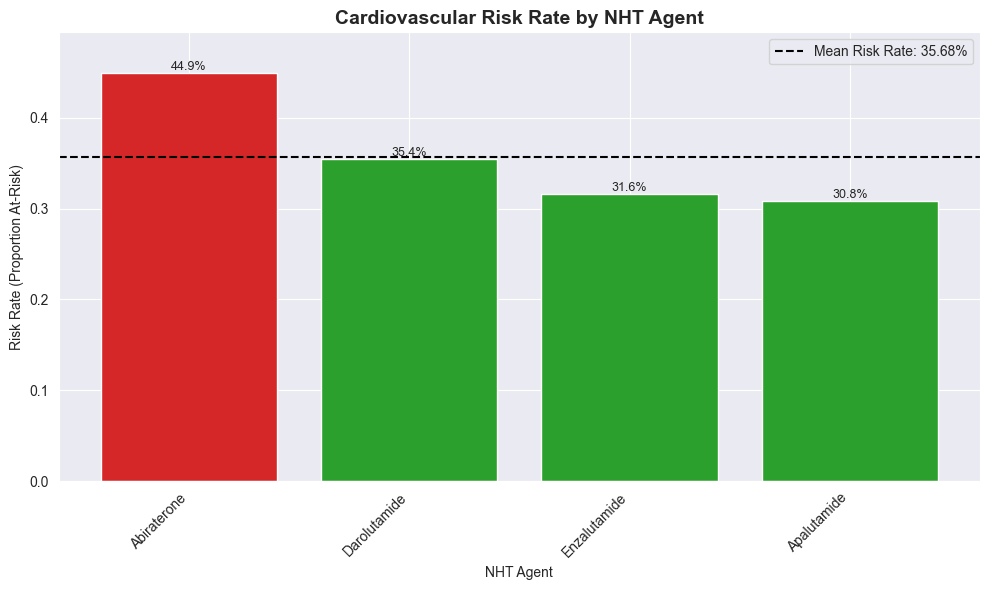

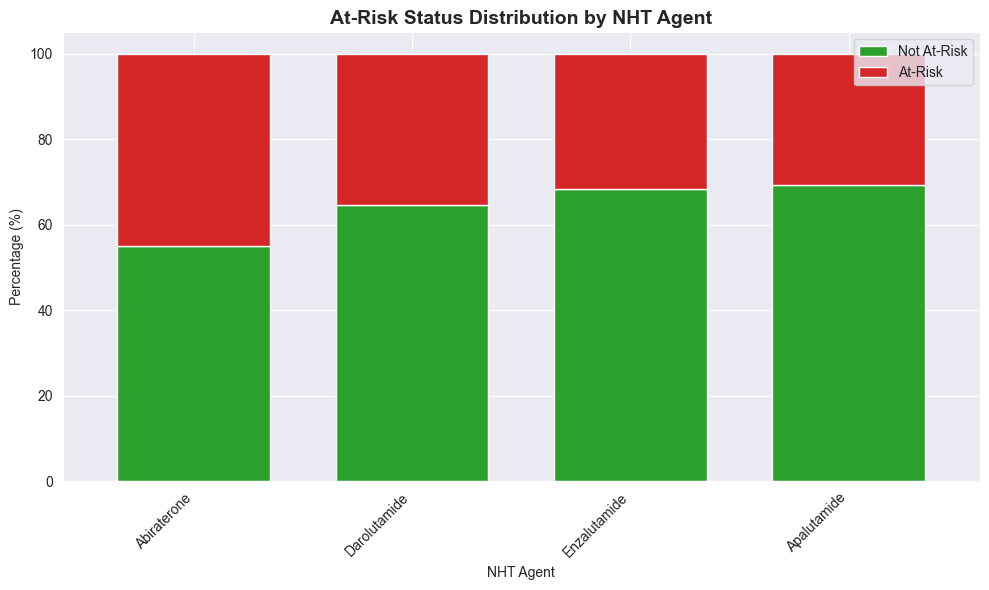

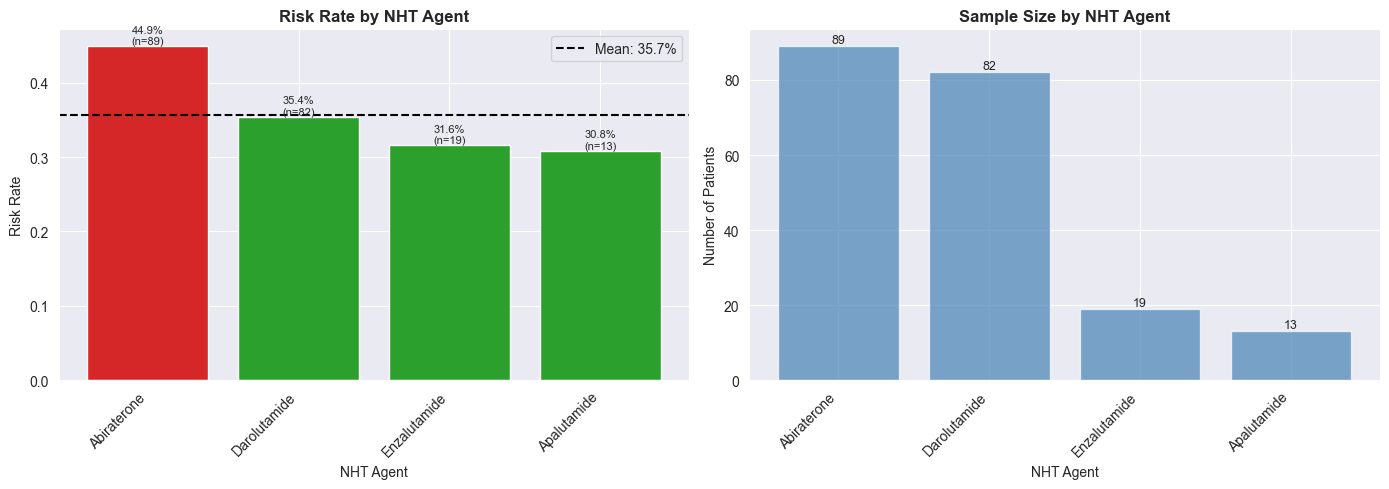


SUMMARY: HIGHEST RISK NHT AGENTS

1. Abiraterone
   Risk Rate: 44.9%
   Patients: 89 (40 at-risk)
   Odds Ratio vs others: 1.57
   P-value vs others: 0.1470 (No)

2. Darolutamide
   Risk Rate: 35.4%
   Patients: 82 (29 at-risk)
   Odds Ratio vs others: 0.78
   P-value vs others: 0.4636 (No)

3. Enzalutamide
   Risk Rate: 31.6%
   Patients: 19 (6 at-risk)
   Odds Ratio vs others: 0.70
   P-value vs others: 0.6235 (No)

4. Apalutamide
   Risk Rate: 30.8%
   Patients: 13 (4 at-risk)
   Odds Ratio vs others: 0.68
   P-value vs others: 0.7699 (No)


RISK ANALYSIS - AGENTS WITH N>=10 ONLY
                   at_risk_count  total_patients  risk_rate
specific_nht_used                                          
Abiraterone                 40.0              89      0.449
Darolutamide                29.0              82      0.354
Enzalutamide                 6.0              19      0.316
Apalutamide                  4.0              13      0.308

Chi-square test (n>=10 agents only):
  Chi2 stat

In [43]:
import os
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
import matplotlib.pyplot as plt
import seaborn as sns


# Load the preprocessed data
BASE_FILE = os.path.join("..", "..", "data", "processed", "cardio_onc_prostate_06_broad_clean.csv")
df = pd.read_csv(BASE_FILE)

print(f"Dataset shape: {df.shape}")
print(f"\nTarget variable distribution:")
print(df['at_risk'].value_counts(dropna = False))

# NHT Agent Risk Analysis

# Filter to patients with NHT agent data and at_risk outcome
analysis_df = df[df['specific_nht_used'].notna() & df['at_risk'].notna()].copy()

print(f"\nPatients with NHT agent and at_risk data: {len(analysis_df)}")
print(f"\nNHT agent distribution:")
print(analysis_df['specific_nht_used'].value_counts())

# Cross-tabulation: NHT agent vs at_risk
crosstab = pd.crosstab(
    analysis_df['specific_nht_used'],
    analysis_df['at_risk'],
    margins = True
)

print("\n" + "=" * 60)
print("CROSS-TABULATION: NHT Agent vs At-Risk Status")
print("=" * 60)
print(crosstab)

# Calculate risk rates by NHT agent
risk_by_nht = analysis_df.groupby('specific_nht_used').agg({
    'at_risk': ['sum', 'count', 'mean']
}).round(3)

risk_by_nht.columns = ['at_risk_count', 'total_patients', 'risk_rate']
risk_by_nht = risk_by_nht.sort_values('risk_rate', ascending = False)

print("\n" + "=" * 60)
print("RISK RATES BY NHT AGENT (Sorted by Risk)")
print("=" * 60)
print(risk_by_nht)

# Statistical significance testing
print("\n" + "=" * 60)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 60)

# Chi-square test for overall association
contingency_table = pd.crosstab(analysis_df['specific_nht_used'], analysis_df['at_risk'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square test:")
print(f"  Chi2 statistic: {chi2:.4f}")
print(f"  P-value: {p_value:.4f}")
print(f"  Degrees of freedom: {dof}")
print(f"  Significant at α=0.05: {'Yes' if p_value < 0.05 else 'No'}")

# Pairwise comparisons (Fisher's exact test for each NHT vs all others)
print("\n" + "=" * 60)
print("PAIRWISE COMPARISONS (Each NHT vs All Others)")
print("=" * 60)

nht_agents = analysis_df['specific_nht_used'].unique()
pairwise_results = []

for nht in nht_agents:
    # Create binary variable: this NHT vs all others
    is_this_nht = (analysis_df['specific_nht_used'] == nht).astype(int)

    # 2x2 contingency table
    table = pd.crosstab(is_this_nht, analysis_df['at_risk'])

    # Fisher's exact test (better for small samples)
    if table.shape == (2, 2):
        odds_ratio, p_val = fisher_exact(table)

        # Calculate risk in this NHT group vs others
        risk_this_nht = analysis_df[analysis_df['specific_nht_used'] == nht]['at_risk'].mean()
        risk_others = analysis_df[analysis_df['specific_nht_used'] != nht]['at_risk'].mean()

        pairwise_results.append({
            'NHT_Agent': nht,
            'Risk_Rate': risk_this_nht,
            'Risk_Rate_Others': risk_others,
            'Odds_Ratio': odds_ratio,
            'P_Value': p_val,
            'Significant': 'Yes' if p_val < 0.05 else 'No'
        })

pairwise_df = pd.DataFrame(pairwise_results).sort_values('Risk_Rate', ascending = False)
print(pairwise_df.to_string(index = False))

# Visualization 1: Risk rates by NHT agent
fig, ax = plt.subplots(figsize = (10, 6))

risk_by_nht_plot = risk_by_nht.reset_index()
bars = ax.bar(
    range(len(risk_by_nht_plot)),
    risk_by_nht_plot['risk_rate'],
    color = ['#d62728' if rate > risk_by_nht_plot['risk_rate'].mean()
             else '#2ca02c' for rate in risk_by_nht_plot['risk_rate']]
)

ax.axhline(
    y = risk_by_nht_plot['risk_rate'].mean(),
    color = 'black',
    linestyle = '--',
    label = f"Mean Risk Rate: {risk_by_nht_plot['risk_rate'].mean():.2%}"
)

ax.set_xticks(range(len(risk_by_nht_plot)))
ax.set_xticklabels(risk_by_nht_plot['specific_nht_used'], rotation = 45, ha = 'right')
ax.set_ylabel('Risk Rate (Proportion At-Risk)')
ax.set_xlabel('NHT Agent')
ax.set_title('Cardiovascular Risk Rate by NHT Agent', fontsize = 14, fontweight = 'bold')
ax.legend()
ax.set_ylim(0, max(risk_by_nht_plot['risk_rate']) * 1.1)

# Add value labels on bars
for i, (bar, rate) in enumerate(zip(bars, risk_by_nht_plot['risk_rate'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height,
            f'{rate:.1%}',
            ha = 'center', va = 'bottom', fontsize = 9)

plt.tight_layout()
# plt.savefig('../outputs/nht_risk_rates.png', dpi = 300, bbox_inches = 'tight')
plt.show()

# Visualization 2: Stacked bar chart showing at-risk vs not at-risk
fig, ax = plt.subplots(figsize = (10, 6))

crosstab_pct = pd.crosstab(
    analysis_df['specific_nht_used'],
    analysis_df['at_risk'],
    normalize = 'index'
) * 100

crosstab_pct = crosstab_pct.loc[risk_by_nht.index]  # Sort by risk rate

crosstab_pct.plot(
    kind = 'bar',
    stacked = True,
    ax = ax,
    color = ['#2ca02c', '#d62728'],
    width = 0.7
)

ax.set_ylabel('Percentage (%)')
ax.set_xlabel('NHT Agent')
ax.set_title('At-Risk Status Distribution by NHT Agent', fontsize = 14, fontweight = 'bold')
ax.legend(['Not At-Risk', 'At-Risk'], loc = 'upper right')
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha = 'right')

plt.tight_layout()
# plt.savefig('../outputs/nht_risk_distribution.png', dpi = 300, bbox_inches = 'tight')
plt.show()

# Visualization 3: Sample size context
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))

# Left: Risk rate with sample size indicators
risk_by_nht_plot = risk_by_nht.reset_index()
colors = ['#d62728' if rate > risk_by_nht_plot['risk_rate'].mean()
          else '#2ca02c' for rate in risk_by_nht_plot['risk_rate']]
bars = ax1.bar(range(len(risk_by_nht_plot)), risk_by_nht_plot['risk_rate'], color = colors)

ax1.axhline(y = risk_by_nht_plot['risk_rate'].mean(), color = 'black', linestyle = '--',
            label = f"Mean: {risk_by_nht_plot['risk_rate'].mean():.1%}")
ax1.set_xticks(range(len(risk_by_nht_plot)))
ax1.set_xticklabels(risk_by_nht_plot['specific_nht_used'], rotation = 45, ha = 'right')
ax1.set_ylabel('Risk Rate')
ax1.set_xlabel('NHT Agent')
ax1.set_title('Risk Rate by NHT Agent', fontweight = 'bold')
ax1.legend()

# Add sample size labels
for i, (bar, n) in enumerate(zip(bars, risk_by_nht_plot['total_patients'])):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2., height,
             f'{height:.1%}\n(n={int(n)})',
             ha = 'center', va = 'bottom', fontsize = 8)

# Right: Sample sizes
ax2.bar(range(len(risk_by_nht_plot)), risk_by_nht_plot['total_patients'],
        color = 'steelblue', alpha = 0.7)
ax2.set_xticks(range(len(risk_by_nht_plot)))
ax2.set_xticklabels(risk_by_nht_plot['specific_nht_used'], rotation = 45, ha = 'right')
ax2.set_ylabel('Number of Patients')
ax2.set_xlabel('NHT Agent')
ax2.set_title('Sample Size by NHT Agent', fontweight = 'bold')

# Add value labels
for i, n in enumerate(risk_by_nht_plot['total_patients']):
    ax2.text(i, n, f'{int(n)}', ha = 'center', va = 'bottom', fontsize = 9)

plt.tight_layout()
# plt.savefig('../outputs/nht_risk_with_sample_size.png', dpi = 300, bbox_inches = 'tight')
plt.show()

# Summary report
print("\n" + "=" * 60)
print("SUMMARY: HIGHEST RISK NHT AGENTS")
print("=" * 60)

top_agents = risk_by_nht.head(len(risk_by_nht))
for idx, (nht, row) in enumerate(top_agents.iterrows(), 1):
    print(f"\n{idx}. {nht}")
    print(f"   Risk Rate: {row['risk_rate']:.1%}")
    print(f"   Patients: {int(row['total_patients'])} ({int(row['at_risk_count'])} at-risk)")

    # Find p-value from pairwise comparison
    p_val = pairwise_df[pairwise_df['NHT_Agent'] == nht]['P_Value'].values[0]
    odds = pairwise_df[pairwise_df['NHT_Agent'] == nht]['Odds_Ratio'].values[0]
    sig = pairwise_df[pairwise_df['NHT_Agent'] == nht]['Significant'].values[0]
    print(f"   Odds Ratio vs others: {odds:.2f}")
    print(f"   P-value vs others: {p_val:.4f} ({sig})")

print("\n" + "=" * 60)

# Additional analysis: Risk by NHT among only those with sufficient sample size (n>=10)
print("\n" + "=" * 60)
print("RISK ANALYSIS - AGENTS WITH N>=10 ONLY")
print("=" * 60)

adequate_sample = risk_by_nht[risk_by_nht['total_patients'] >= 10].copy()
print(adequate_sample)

if len(adequate_sample) > 1:
    # Rerun chi-square for adequate sample agents only
    adequate_df = analysis_df[analysis_df['specific_nht_used'].isin(adequate_sample.index)]
    contingency_table_adequate = pd.crosstab(adequate_df['specific_nht_used'],
                                             adequate_df['at_risk'])
    chi2_adeq, p_value_adeq, dof_adeq, expected_adeq = chi2_contingency(contingency_table_adequate)

    print(f"\nChi-square test (n>=10 agents only):")
    print(f"  Chi2 statistic: {chi2_adeq:.4f}")
    print(f"  P-value: {p_value_adeq:.4f}")
    print(f"  Significant at α=0.05: {'Yes' if p_value_adeq < 0.05 else 'No'}")